# Systematic uncertainty breakdown (final selected variables)

This notebook loads the precomputed systematic covariance files written by the workflow drivers:

- `run_syst_cosmics_chunked.sh` -> `Cosmics/cosmics_syst_dict.npz`
- `run_syst_multisim_chunked.sh` -> `MCstat/`, `Flux/`, `G4/`
- `run_syst_detvar_chunked.sh` -> `Detector/detector_syst_dict.npz`
- `run_syst_genie_chunked.sh` (seeded/produced elsewhere) -> `GENIE/cov_mat_dict.pkl`

It then computes, **for each final selected variable**:

1. **Per-category fractional uncertainty breakdown** (same style as the flux-by-knob example): Flux, G4, Detector (per WireMod/calo tag where available), and GENIE — as **two separate figures** for **rate** and **xsec** (each: per-knob curves plus category total).
2. **Category totals + summed covariance** as **two separate single-panel figures**: (a) per-category curves for Flux, G4, Detector, and **GENIE rate (total)** plus **sqrt(diag(C_Flux + C_G4 + C_Detector + C_GENIE_rate))**; (b) the same with **GENIE xsec (total)** and **sqrt(diag(C_Flux + C_G4 + C_Detector + C_GENIE_xsec))**. Saved as `syst_break_totals_rate__*` and `syst_break_totals_xsec__*`.
3. (Planned elsewhere in this notebook) A **summary** of integrated-rate uncertainty contributions and **top bin drivers** per source.

## Notes on the decomposition
The integrated-rate fractional variance for a variable with `n` bins is:

V = 1^T C 1

where `C` is the source fractional covariance matrix and `1` is an `n`-vector of ones.

For ranking “top drivers” we compute the per-bin signed variance contributions:

t_i = (C * 1)_i

and rank by `|t_i|`.


In [1]:
import os
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.dataset_locations import default_syst_disk_root, PLOTS_BASE
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
    with_final_selected_evt_variables,
)
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig

from analysis_village.numucc_1p0pi import utils as _numu_utils  # presentation.mplstyle, dpi



In [2]:
# ----------------------------
# User configuration
# ----------------------------

# Root of the syst_disk_layout tree. Must contain:
#   MCstat/mcstat_syst_dict.npz
#   Flux/flux_syst_dict.npz
#   G4/g4_syst_dict.npz
#   Cosmics/cosmics_syst_dict.npz
#   Detector/detector_syst_dict.npz
#   GENIE/cov_mat_dict.pkl
SYST_DISK_ROOT = os.environ.get('NUMUCC_SYST_DISK_ROOT', None)
if not SYST_DISK_ROOT:
    SYST_DISK_ROOT = str(default_syst_disk_root())
SYST_DISK_ROOT = str(Path(SYST_DISK_ROOT).expanduser())

# Subset of variables to plot (None = all final selected)
# Provide strings like 'integrated', 'muon-p', etc.
VARS_TO_PLOT = None

# Output directory for figures
OUT_DIR = Path(PLOTS_BASE) / 'syst_uncertainty_breakdown' / 'final_selected'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# If True, run the last cell to write Flux/G4/Detector/GENIE (rate + xsec as separate PNGs)/totals for every variable in ``var_configs`` (slow).
SAVE_ALL_BREAKDOWN_PNGS = False

# Sources to include
SOURCES = ['Flux', 'G4', 'detvar', 'cosmic', 'GENIE']

# Top-k bin drivers per source
TOP_K = 5

print('SYST_DISK_ROOT =', SYST_DISK_ROOT)
print('OUT_DIR       =', str(OUT_DIR))


SYST_DISK_ROOT = /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk
OUT_DIR       = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/syst_uncertainty_breakdown/final_selected


In [3]:
# ----------------------------
# Variable catalogue
# ----------------------------

var_configs = with_final_selected_evt_variables(list(CORE_SELECTED_EVT_VARIABLE_CONFIGS))

if VARS_TO_PLOT is not None:
    allowed = set(VARS_TO_PLOT)
    var_configs = [vc for vc in var_configs if vc.var_save_name in allowed]

var_names = [vc.var_save_name for vc in var_configs]
print(f'Final selected variables: {len(var_names)}')
print(' - ' + ', '.join(var_names))


Final selected variables: 23
 - integrated, muon-p, muon-dir_z, proton-p, proton-dir_z, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_p, tki-del_alpha, tki-del_phi, muon-dir_phi, proton-dir_phi, muon-dir_x, muon-dir_y, proton-dir_x, proton-dir_y, vertex_x, vertex_y, vertex_z, muon-end_x, muon-end_y, muon-end_z


In [4]:
# ----------------------------
# Load covariance payloads
# ----------------------------

from analysis_village.numucc_1p0pi.syst_disk_layout import syst_disk_paths

paths = syst_disk_paths(SYST_DISK_ROOT)

needed = {
    'flux_npz': paths['flux'],
    'g4_npz': paths['g4'],
    'cosmics_npz': paths['cosmics'],
    'detector_npz': paths['detector'],
    'genie_npz': paths['genie'],
}

missing = [k for k, p in needed.items() if not Path(p).is_file()]
if missing:
    raise FileNotFoundError(
        "Missing required syst files:\n" + '\n'.join(f"  {k}: {needed[k]}" for k in missing)
    )

flux_npz = np.load(needed['flux_npz'], allow_pickle=True)
g4_npz = np.load(needed['g4_npz'], allow_pickle=True)
cosmics_npz = np.load(needed['cosmics_npz'], allow_pickle=True)
detector_npz = np.load(needed['detector_npz'], allow_pickle=True)
genie_npz = np.load(needed['genie_npz'], allow_pickle=True)
genie_blob = None
_genie_path = paths['genie']
if Path(_genie_path).is_file():
    with open(_genie_path, 'rb') as gf:
        genie_blob = pickle.load(gf)
    print('Loaded GENIE:', _genie_path)
else:
    print('GENIE pickle not found (GENIE plots skipped):', _genie_path)

print('Loaded syst covariance payloads.')


Loaded GENIE: /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk/GENIE/cov_mat_dict.pkl
Loaded syst covariance payloads.


/tmp/ipykernel_1954510/824954098.py:32: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  genie_blob = pickle.load(gf)


In [7]:
# ----------------------------
# Helpers: fractional unc from cov_frac and per-category breakdown plots
# (axis style matches ``unfolding-data.ipynb`` ``get_syst_unc(..., plot=True)``.)
# ----------------------------


def frac_unc_diag(cov_frac):
    c = np.asarray(cov_frac, dtype=np.float64)
    return np.nan_to_num(np.sqrt(np.diag(c)), nan=0.0, posinf=0.0, neginf=0.0)


def frac_unc_pct(cov_frac):
    """Same diagonal uncertainty as ``unfolding-data.ipynb`` ``get_syst_unc`` (fractional; y-axis label matches that notebook)."""
    return frac_unc_diag(cov_frac)




def style_uncertainty_axis(ax, var_config, pct_series_list, title=None):
    """Grid, limits, and legend like ``unfolding-data.ipynb``."""
    if title is not None:
        ax.set_title(title)
    flat = [np.asarray(s, dtype=np.float64).ravel() for s in pct_series_list if s is not None and len(s)]
    ymax = max((np.nanmax(np.where(np.isfinite(x), x, 0.0)) for x in flat), default=0.0)
    ax.set_xlim(var_config.bins[0], var_config.bins[-1])
    ax.set_ylim(0, max(ymax * 1.4, 1e-9))
    ax.set_xlabel(var_config.var_labels[1] if getattr(var_config, "var_labels", None) else var_config.var_save_name)
    ax.set_ylabel("Uncertainty [%]")
    ax.legend(fontsize=11, ncol=3, loc="upper center")
    ax.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.minorticks_on()


def plot_knob_breakdown(ax, var_config, by_knob, total_cov_frac, title):
    bins = var_config.bins
    bc = var_config.bin_centers
    pct_list = []
    if by_knob:
        for kn in sorted(by_knob.keys()):
            cf = by_knob[kn]["cov_frac"]
            w = frac_unc_pct(cf)
            pct_list.append(w)
            ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2, label=str(kn))
    wtot = frac_unc_pct(total_cov_frac)
    pct_list.append(wtot)
    ax.hist(bc, bins=bins, weights=wtot, histtype="step", linewidth=2, color="k", label="Total")
    style_uncertainty_axis(ax, var_config, pct_list, title=title)


def detector_by_tag_dict(det_npz, var_name):
    """Return {tag_label: cov_frac} plus combined total from ``detector`` key.

    Prefer ``detector_by_wiremod`` (Flux/G4 ``*_by_knob``-style nesting); fall back
    to legacy ``detector-<tag>`` top-level keys."""
    z = dict(det_npz)
    combined = z["detector"]
    comb_item = combined.item() if hasattr(combined, "item") else combined
    total = comb_item[var_name]["cov_frac"]
    dbw = z.get("detector_by_wiremod")
    if dbw is not None:
        cell = dbw.item() if hasattr(dbw, "item") else dbw
        if isinstance(cell, dict) and var_name in cell:
            per_var = cell[var_name]
            out = {tag: pack["cov_frac"] for tag, pack in sorted(per_var.items())}
            return out, total
    out = {}
    for k in sorted(z.keys()):
        if not k.startswith("detector-"):
            continue
        tag = k[len("detector-") :]
        item = z[k].item() if hasattr(z[k], "item") else z[k]
        if var_name not in item:
            continue
        out[tag] = item[var_name]["cov_frac"]
    return out, total


def genie_var_dict(genie_blob, var_name):
    if genie_blob is None or var_name not in genie_blob:
        return None
    return genie_blob[var_name]


def genie_knob_covs(gd):
    """Split pickle entry into per-knob rate/xsec cov_frac dicts and totals."""
    if gd is None:
        return None
    rate_parts, xsec_parts = {}, {}
    rate_total = xsec_total = None
    for k, v in gd.items():
        if not isinstance(v, np.ndarray) or v.ndim != 2:
            continue
        if k == "genie":
            xsec_total = v
        elif k == "genie_rate":
            rate_total = v
        elif k.endswith("_rate"):
            rate_parts[k[: -len("_rate")]] = v
        else:
            xsec_parts[k] = v
    return {
        "rate_parts": rate_parts,
        "xsec_parts": xsec_parts,
        "rate_total": rate_total,
        "xsec_total": xsec_total,
    }


def _sum_cov_frac_matrices(matrices):
    """Sum square fractional covariance matrices (independent knobs)."""
    total = None
    for m in matrices:
        arr = np.asarray(m, dtype=np.float64)
        total = arr if total is None else total + arr
    return total


def genie_category_cov_frac(genie_pack, kind):
    """Combined GENIE fractional covariance for ``rate`` or ``xsec`` (total matrix or sum of per-knob parts)."""
    if genie_pack is None:
        return None
    if kind == "rate":
        if genie_pack["rate_total"] is not None:
            return np.asarray(genie_pack["rate_total"], dtype=np.float64)
        parts = genie_pack.get("rate_parts") or {}
        if not parts:
            return None
        return _sum_cov_frac_matrices(parts.values())
    if genie_pack["xsec_total"] is not None:
        return np.asarray(genie_pack["xsec_total"], dtype=np.float64)
    parts = genie_pack.get("xsec_parts") or {}
    if not parts:
        return None
    return _sum_cov_frac_matrices(parts.values())


def plot_genie_rate_breakdown(ax, var_config, genie_pack):
    bins = var_config.bins
    bc = var_config.bin_centers
    rp = genie_pack["rate_parts"]
    pct0 = []
    if rp:
        for kn in sorted(rp.keys()):
            w = frac_unc_pct(rp[kn])
            pct0.append(w)
            ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2) #, label=str(kn))
    if genie_pack["rate_total"] is not None:
        w = frac_unc_pct(genie_pack["rate_total"])
        pct0.append(w)
        ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2, color="k", label="Total (rate)")
    style_uncertainty_axis(ax, var_config, pct0, title="GENIE — rate (per knob)")


def plot_genie_xsec_breakdown(ax, var_config, genie_pack):
    bins = var_config.bins
    bc = var_config.bin_centers
    xp = genie_pack["xsec_parts"]
    pct1 = []
    if xp:
        for kn in sorted(xp.keys()):
            w = frac_unc_pct(xp[kn])
            pct1.append(w)
            ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2) #, label=str(kn))
    if genie_pack["xsec_total"] is not None:
        w = frac_unc_pct(genie_pack["xsec_total"])
        pct1.append(w)
        ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2, color="k", label="Total (xsec)")
    style_uncertainty_axis(ax, var_config, pct1, title="GENIE — cross section (per knob)")


def category_total_fracs(vsn, flux_npz, g4_npz, detector_npz, genie_pack):
    """Per-bin sqrt(diag(C)) for combined Flux / G4 / Detector / GENIE rate / GENIE xsec."""
    fu = frac_unc_diag(flux_npz[vsn].item()["flux"]["cov_frac"])
    gu = frac_unc_diag(g4_npz[vsn].item()["G4"]["cov_frac"])
    det_item = dict(detector_npz)["detector"].item()
    du = frac_unc_diag(det_item[vsn]["cov_frac"])
    gr = gx = None
    if genie_pack is not None:
        c_rate = genie_category_cov_frac(genie_pack, "rate")
        if c_rate is not None:
            gr = frac_unc_diag(c_rate)
        c_xsec = genie_category_cov_frac(genie_pack, "xsec")
        if c_xsec is not None:
            gx = frac_unc_diag(c_xsec)
    return fu, gu, du, gr, gx


def summed_cov_total_frac(vsn, flux_npz, g4_npz, detector_npz, genie_pack, genie_kind):
    """sqrt(diag(sum of category cov_frac)). genie_kind: 'rate' or 'xsec'."""
    cf = flux_npz[vsn].item()["flux"]["cov_frac"]
    cg = g4_npz[vsn].item()["G4"]["cov_frac"]
    cd = dict(detector_npz)["detector"].item()[vsn]["cov_frac"]
    s = np.asarray(cf, dtype=np.float64) + np.asarray(cg, dtype=np.float64) + np.asarray(cd, dtype=np.float64)
    gc = genie_category_cov_frac(genie_pack, genie_kind) if genie_pack is not None else None
    if gc is not None:
        s = s + np.asarray(gc, dtype=np.float64)
    return frac_unc_diag(s)


def plot_category_totals_single_panel(ax, var_config, flux_npz, g4_npz, detector_npz, genie_pack, genie_kind):
    """One axis: Flux, G4, Detector, GENIE rate OR xsec total, and summed covariance (black)."""
    vsn = var_config.var_save_name
    bins = var_config.bins
    bc = var_config.bin_centers
    fu, gu, du, gr, gx = category_total_fracs(vsn, flux_npz, g4_npz, detector_npz, genie_pack)
    pct_list = []
    for w, lab in (
        (fu, "Flux (total)"),
        (gu, "G4 (total)"),
        (du, "Detector (total)"),
    ):
        pct_list.append(w)
        ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2, label=lab)
    _gcol = "#D95F02"
    if genie_kind == "rate" and gr is not None:
        pct_list.append(gr)
        ax.hist(
            bc,
            bins=bins,
            weights=gr,
            histtype="step",
            linewidth=2,
            facecolor=_gcol,
            edgecolor=_gcol,
            label="GENIE rate (total)",
        )
    elif genie_kind == "xsec" and gx is not None:
        pct_list.append(gx)
        ax.hist(
            bc,
            bins=bins,
            weights=gx,
            histtype="step",
            linewidth=2,
            facecolor=_gcol,
            edgecolor=_gcol,
            label="GENIE xsec (total)",
        )
    grand = summed_cov_total_frac(vsn, flux_npz, g4_npz, detector_npz, genie_pack, genie_kind)
    pct_list.append(grand)
    if genie_kind == "rate":
        grand_lab = "sqrt(diag(C_Flux + C_G4 + C_Det + C_GENIE_rate))"
        title = "Category totals + covariance sum (GENIE rate)"
    else:
        grand_lab = "sqrt(diag(C_Flux + C_G4 + C_Det + C_GENIE_xsec))"
        title = "Category totals + covariance sum (GENIE xsec)"
    ax.hist(
        bc,
        bins=bins,
        weights=grand,
        histtype="step",
        linewidth=2,
        color="k",
        label=grand_lab,
    )
    style_uncertainty_axis(ax, var_config, pct_list, title=title)


def plot_all_syst_breakdowns_for_var(var_config, flux_npz, g4_npz, detector_npz, genie_blob, out_dir=None, show=True):
    vsn = var_config.var_save_name
    bins = var_config.bins
    bc = var_config.bin_centers
    save_kw = dict(bbox_inches="tight", dpi=_numu_utils.dpi)

    # --- Flux ---
    fig, ax = plt.subplots()
    cell = flux_npz[vsn].item()
    plot_knob_breakdown(ax, var_config, cell.get("flux_by_knob"), cell["flux"]["cov_frac"], f"Flux breakdown — {vsn}")
    fig.tight_layout()
    if out_dir:
        fig.savefig(Path(out_dir) / f"syst_break_flux__{vsn}.png", **save_kw)
    if show:
        plt.show()
    else:
        plt.close(fig)

    # --- G4 ---
    fig, ax = plt.subplots()
    cell = g4_npz[vsn].item()
    plot_knob_breakdown(ax, var_config, cell.get("G4_by_knob"), cell["G4"]["cov_frac"], f"G4 breakdown — {vsn}")
    fig.tight_layout()
    if out_dir:
        fig.savefig(Path(out_dir) / f"syst_break_g4__{vsn}.png", **save_kw)
    if show:
        plt.show()
    else:
        plt.close(fig)

    # --- Detector ---
    fig, ax = plt.subplots()
    by_tag, tot = detector_by_tag_dict(detector_npz, vsn)
    pct_list = []
    if by_tag:
        for tag in sorted(by_tag.keys()):
            w = frac_unc_pct(by_tag[tag])
            pct_list.append(w)
            ax.hist(bc, bins=bins, weights=w, histtype="step", linewidth=2, label=tag)
    wtot = frac_unc_pct(tot)
    pct_list.append(wtot)
    ax.hist(bc, bins=bins, weights=wtot, histtype="step", linewidth=2, color="k", label="Total")
    style_uncertainty_axis(ax, var_config, pct_list, title=f"Detector breakdown — {vsn}")
    fig.tight_layout()
    if out_dir:
        fig.savefig(Path(out_dir) / f"syst_break_detector__{vsn}.png", **save_kw)
    if show:
        plt.show()
    else:
        plt.close(fig)

    # --- GENIE: separate figures for rate and xsec ---
    gd = genie_var_dict(genie_blob, vsn)
    genie_pack = genie_knob_covs(gd)
    if genie_pack is not None and (
        genie_pack["rate_parts"]
        or genie_pack["xsec_parts"]
        or genie_pack["rate_total"] is not None
        or genie_pack["xsec_total"] is not None
    ):
        has_rate = bool(genie_pack["rate_parts"]) or genie_pack["rate_total"] is not None
        has_xsec = bool(genie_pack["xsec_parts"]) or genie_pack["xsec_total"] is not None
        if has_rate:
            fig_r, ax_r = plt.subplots()
            plot_genie_rate_breakdown(ax_r, var_config, genie_pack)
            fig_r.suptitle(f"GENIE rate — {vsn}", y=1.02)
            fig_r.tight_layout()
            if out_dir:
                fig_r.savefig(Path(out_dir) / f"syst_break_genie_rate__{vsn}.png", **save_kw)
            if show:
                plt.show()
            else:
                plt.close(fig_r)
        if has_xsec:
            fig_x, ax_x = plt.subplots(figsize=(10, 5))
            plot_genie_xsec_breakdown(ax_x, var_config, genie_pack)
            fig_x.suptitle(f"GENIE xsec — {vsn}", y=1.02)
            fig_x.tight_layout()
            if out_dir:
                fig_x.savefig(Path(out_dir) / f"syst_break_genie_xsec__{vsn}.png", **save_kw)
            if show:
                plt.show()
            else:
                plt.close(fig_x)
    else:
        genie_pack = None

    # --- Category totals + grand total: two separate single-panel figures (rate vs xsec GENIE) ---
    for kind, fname in (("rate", "syst_break_totals_rate__"), ("xsec", "syst_break_totals_xsec__")):
        fig, ax = plt.subplots()
        plot_category_totals_single_panel(ax, var_config, flux_npz, g4_npz, detector_npz, genie_pack, kind)
        fig.suptitle(f"Category totals ({kind}) — {vsn}", y=1.02)
        fig.tight_layout()
        if out_dir:
            fig.savefig(Path(out_dir) / f"{fname}{vsn}.png", **save_kw)
        if show:
            plt.show()
        else:
            plt.close(fig)



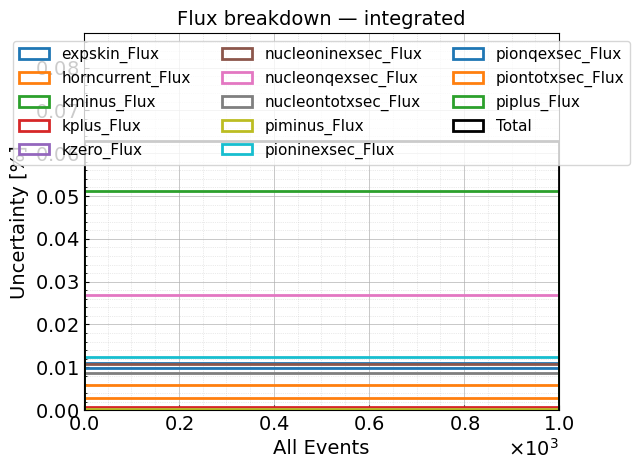

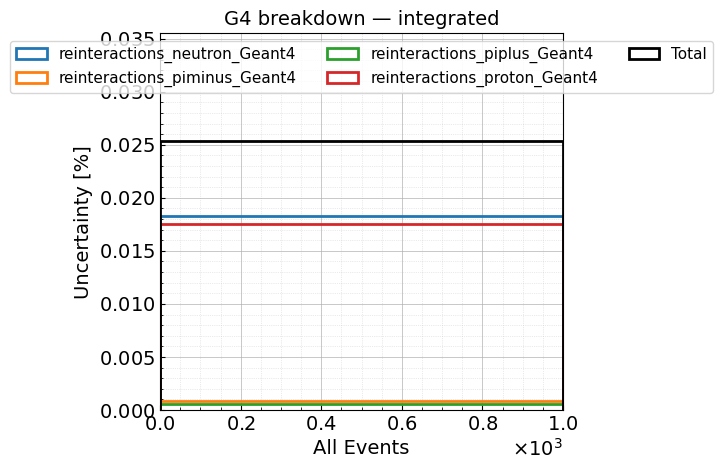

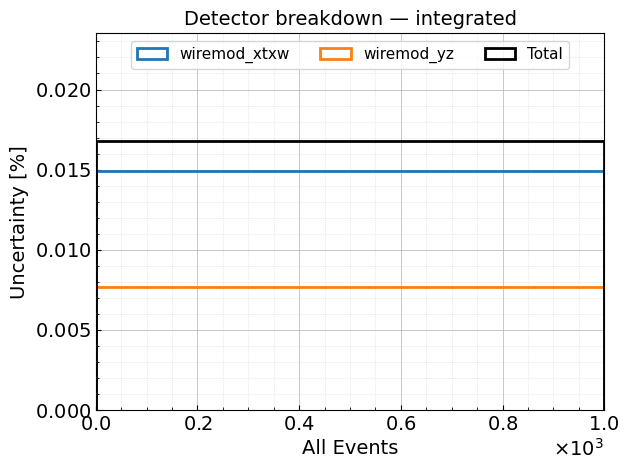

/tmp/ipykernel_1954510/3639554386.py:326: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig_r.tight_layout()


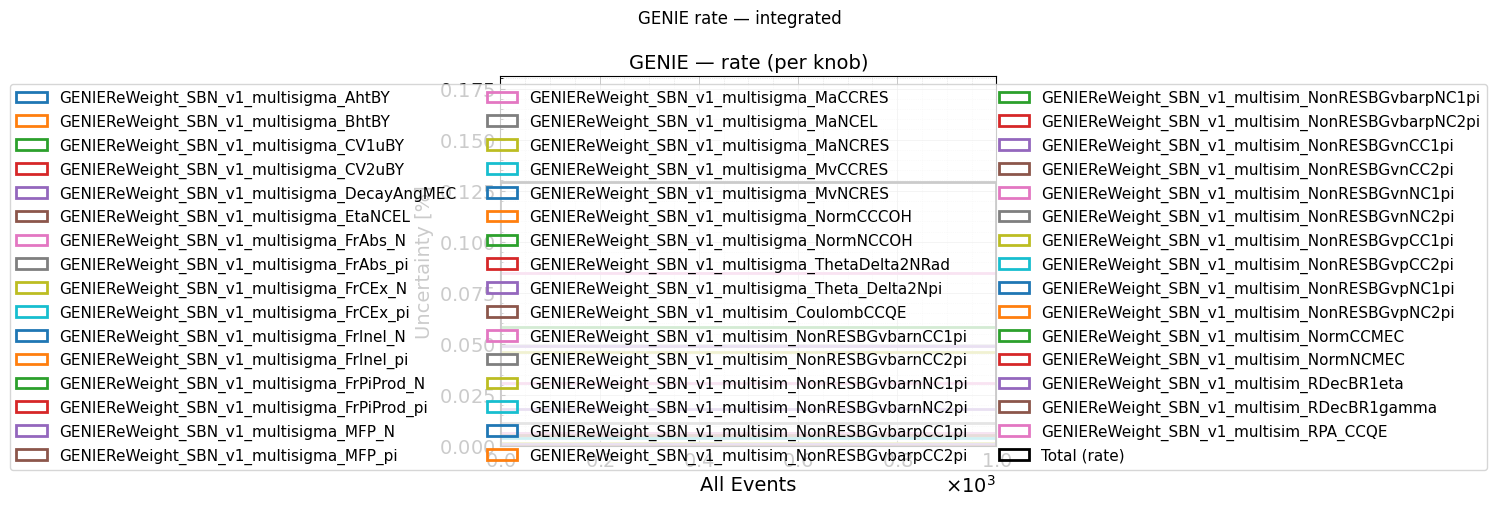

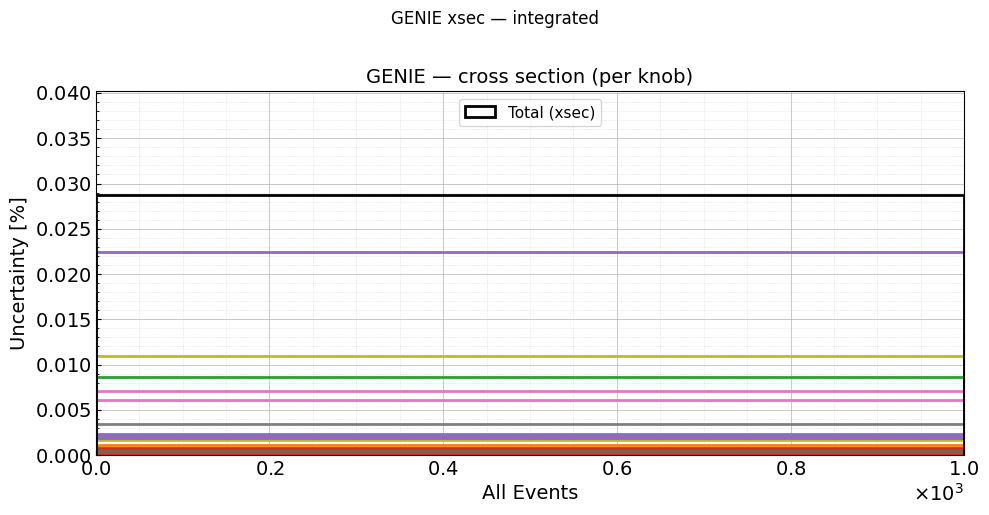

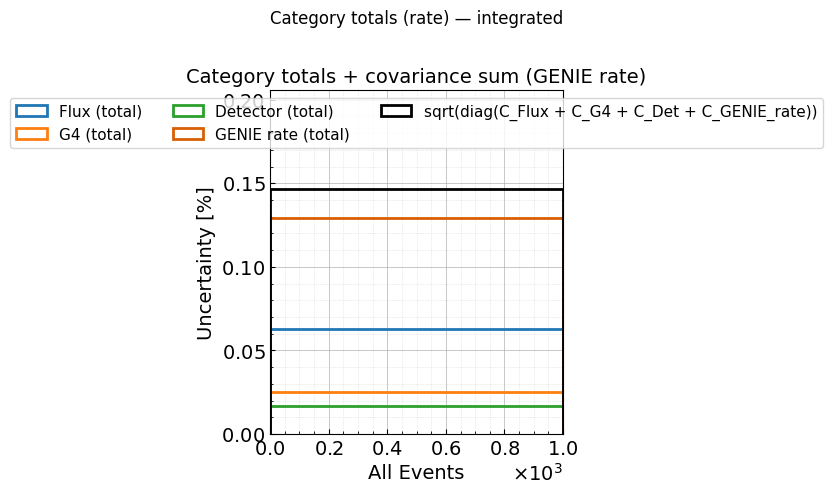

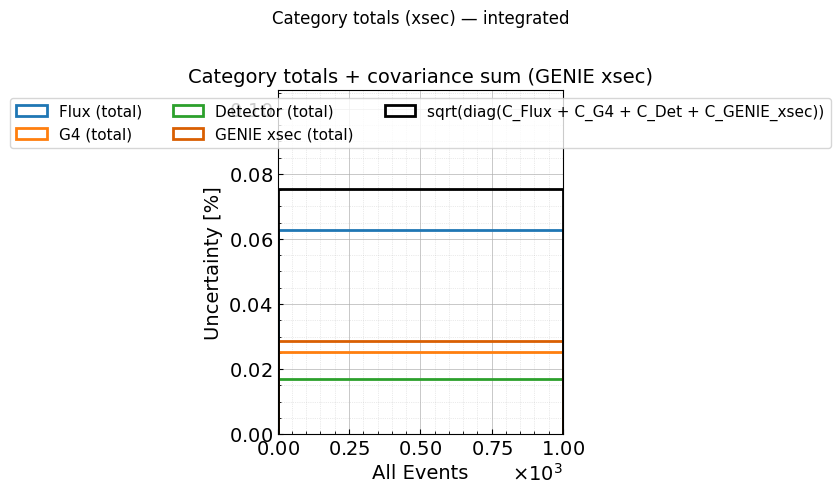

In [6]:
# Example: one variable on screen (same style as the old flux-only cell)
DEMO_VAR_CONFIG = VariableConfig.all_events()
plot_all_syst_breakdowns_for_var(
    DEMO_VAR_CONFIG,
    flux_npz,
    g4_npz,
    detector_npz,
    genie_blob,
    out_dir=None,
    show=True,
)

In [99]:
# Optional: write the same breakdown set for every variable in ``var_configs`` (several PNGs per variable)
if SAVE_ALL_BREAKDOWN_PNGS:
    for vc in var_configs:
        plot_all_syst_breakdowns_for_var(
            vc,
            flux_npz,
            g4_npz,
            detector_npz,
            genie_blob,
            out_dir=OUT_DIR,
            show=False,
        )
    print('Wrote figures under', OUT_DIR)
else:
    print('Skipping bulk export (set SAVE_ALL_BREAKDOWN_PNGS=True in the config cell to write PNGs for all variables).')

Skipping bulk export (set SAVE_ALL_BREAKDOWN_PNGS=True in the config cell to write PNGs for all variables).
